In [1]:
import sys, os
from scipy.stats import qmc
import matplotlib.pyplot as plt
import numpy as np

repo_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)
print("Added to sys.path:/", repo_root)
from fixedincomelib import *
from IPython.display import display

print("Fixed Income Library is loaded.")

Added to sys.path:/ c:\Harsh\NYU\SEM4\FRE-9743\FRE-GT-9743-Assignment-8
Fixed Income Library is loaded.


# 1. SABR Conversion

The SABR model is a stochastic volatility model developed by Hagan et al. The dynamics of the forward rate \(F(t)\) are:

$
dF(t)=\sigma(t)F^\beta(t)dW_1(t)
$

$
d\sigma(t)=\nu\sigma(t)dW_2(t)
$

$
dW_1 dW_2 = \rho dt
$

with initial conditions:

$
F(0)=F_0
$

$
\sigma(0)=\alpha
$

---

Using asymptotic expansion techniques, the equivalent Black volatility can be written as:

$
\sigma_{LN}^{B} =
\frac{\alpha}{(FK)^{(1-\beta)/2}}
\frac{z}{x(z)}
\omega_1
\left(1+\omega_2 T + \cdots \right)
$

---

### Definitions

$
z =
\frac{\nu}{\alpha}
(FK)^{(1-\beta)/2}
\log(F/K)
$

$
x(z) =
\log\left(
\frac{\sqrt{1-2\rho z+z^2}+z-\rho}{1-\rho}
\right)
$

$
\omega_1 =
1+
\frac{(1-\beta)^2}{24}\log^2(F/K)
+
\frac{(1-\beta)^4}{1920}\log^4(F/K)
+\cdots
$

$
\omega_2 =
\frac{(1-\beta)^2}{24}
\frac{\alpha^2}{(FK)^{1-\beta}}
+
\frac{1}{4}
\frac{\alpha\beta\rho\nu}{(FK)^{(1-\beta)/2}}
+
\frac{2-3\rho^2}{24}\nu^2
$

---

## Hagan's formula expansion around ATM

Notice that:

$
\frac{z}{x}=
\frac{z}
{\log\left(
\frac{\sqrt{1-2\rho z+z^2}+z-\rho}{1-\rho}
\right)}
$

This expression becomes indeterminate at \(z=0\), which corresponds to:

$
K=F
$

For small $z$, we use a Taylor expansion:

$
\frac{z}{x}
\approx 1
-\frac{1}{2}\rho z +
\left(
-\frac{1}{4}\rho^2+\frac{1}{6}
\right)z^2 -
\left(
\frac{1}{4}\rho^2-\frac{5}{24}
\right)\rho z^3+
\left(
-\frac{5}{16}\rho^4
+\frac{1}{3}\rho^2
-\frac{17}{360}
\right)z^4-
\left(
\frac{7}{16}\rho^4
-\frac{55}{96}\rho^2
+\frac{37}{240}
\right)\rho z^5
$

This expansion is typically sufficient when:

$
|z|<0.01
$

---

When the strike is very close to zero or very large, the density derived from the equivalent Black volatility may become negative or unstable. This motivates corrections to the wings of the Hagan expansion.

According to the readings above, please complete the functions referenced in `sabr.py`.

You may use the API provided above to implement both the volatility and risk functions. After that, run the code blocks below.

In [2]:
# utilities
def display_res(input_dict: Dict[SimpleMetrics, float]):
    display({k.to_string(): v for k, v in input_dict.items()})

# Bump and reval
def bump_and_reval_gradients(func, value_key: str, base: Dict[str, Any], bump_inputs: List[str], bump_size: float = 1e-4):
    print(f"----- Calculating gradients for {value_key.value} with bump size {bump_size} -----")
    for metric in bump_inputs:
        base_copy = base.copy()
        base_copy[metric] += bump_size
        res_up = func(**base_copy)

        base_copy[metric] -= 2 * bump_size
        res_dn = func(**base_copy)
        gradient = (res_up[value_key] - res_dn[value_key]) / (2 * bump_size)
        print(f"d_{value_key.value}_d_{metric}: {gradient}")

In [3]:
### 1.1 hagan's classic formula
alpha = 0.11
beta = 0.6
nu = 0.5
rho = 0.5
shift = 0.04
forward = 0.04
strike = 0.042
tte = 0.5

res_imp_log_normal_vol = qfEuropeanOptionSABRLogNormalSigma(
    forward, strike, tte, alpha, beta, rho, nu, shift, True
)
display_res(res_imp_log_normal_vol)

{'implied_log_normal_vol': np.float64(0.30753370804464425),
 'd_ln_sigma_d_alpha': np.float64(2.7836494264635094),
 'd_ln_sigma_d_beta': np.float64(-0.7671990084031498),
 'd_ln_sigma_d_rho': np.float64(0.0047994361581260095),
 'd_ln_sigma_d_nu': np.float64(0.0177892284379364),
 'd_ln_sigma_d_forward': np.float64(-2.3980198155653625),
 'd_ln_sigma_d_strike': np.float64(0.8458659814736222),
 'd_ln_sigma_d_tte': np.float64(0.007562343085309908),
 'd_ln_sigma_d_strike_strike': np.float64(14.983951453906153)}

In [4]:
# 1.2 alpha from atm_lognormal_sigma and its sensitivity w.r.t atm_lognormal_sigma, beta, rho, nu, TTE, forward
res_imp_alpha = SABRAnalytics.alpha_from_atm_lognormal_sigma(forward, tte, res_imp_log_normal_vol[SimpleMetrics.IMPLIED_LOG_NORMAL_VOL],beta,rho, nu, shift, True)
display_res(res_imp_alpha)

# Validate gradients using bump and reval
bump_and_reval_gradients(
    SABRAnalytics.alpha_from_atm_lognormal_sigma, 
    SabrMetrics.ALPHA,
    {
        "forward": forward,
        "time_to_expiry": tte,
        "sigma_atm_lognormal": res_imp_log_normal_vol[SimpleMetrics.IMPLIED_LOG_NORMAL_VOL],
        "beta": beta,
        "rho": rho,
        "nu": nu,
        "shift": shift
    }, 
    ["sigma_atm_lognormal", "beta", "rho", "nu", "time_to_expiry", "forward"], 
)

{'alpha': np.float64(0.11059312846026506),
 'd_alpha_d_ln_sigma_atm': np.float64(0.3573857869956698),
 'd_alpha_d_tte': np.float64(-0.0027165535724301792),
 'd_alpha_d_beta': np.float64(0.27846481604093964),
 'd_alpha_d_nu': np.float64(-0.004063202778795216),
 'd_alpha_d_rho': np.float64(0.00045970969999717555),
 'd_alpha_d_forward': np.float64(0.5529656423013253)}

----- Calculating gradients for alpha with bump size 0.0001 -----
d_alpha_d_sigma_atm_lognormal: 0.3573857869874908
d_alpha_d_beta: 0.27846481897839115
d_alpha_d_rho: 0.0004597096998903982
d_alpha_d_nu: -0.0040632027765996614
d_alpha_d_time_to_expiry: -0.0027165535724377188
d_alpha_d_forward: 0.5529657805428134


In [5]:
# 1.3 alpha from atm_normal_sigma and its sensitivity w.r.t atm_normal_sigma, beta, rho, nu, TTE, forward
res_imp_alpha_atm_normal = SABRAnalytics.alpha_from_atm_normal_sigma(forward, tte, 0.025, beta, rho, nu, shift, True, tol = 1e-8)
display_res(res_imp_alpha_atm_normal)

# Validate gradients using bump and reval
bump_and_reval_gradients(
    SABRAnalytics.alpha_from_atm_normal_sigma, 
    SabrMetrics.ALPHA,
    {
        "forward": forward,
        "time_to_expiry": tte,
        "sigma_atm_normal": 0.025,
        "beta": beta,
        "rho": rho,
        "nu": nu,
        "shift": shift
    }, 
    ["sigma_atm_normal", "beta", "rho", "nu", "time_to_expiry", "forward"], 
)

{'alpha': np.float64(0.11259596768140434),
 'd_alpha_d_normal_sigma_atm': np.float64(4.493725787497929),
 'd_alpha_d_beta': np.float64(0.2834952314473653),
 'd_alpha_d_nu': np.float64(-0.004158604071784488),
 'd_alpha_d_rho': np.float64(0.0004451338206182542),
 'd_alpha_d_tte': np.float64(-0.0023321250298475624),
 'd_alpha_d_forward': np.float64(-0.8413094345977603)}

----- Calculating gradients for alpha with bump size 0.0001 -----
d_alpha_d_sigma_atm_normal: 4.493725119309317
d_alpha_d_beta: 0.283495234437367
d_alpha_d_rho: 0.0004451338206368227
d_alpha_d_nu: -0.004158604069437466
d_alpha_d_time_to_expiry: -0.0023321449768576308
d_alpha_d_forward: -0.8413101356615632


In [6]:
# 1.4  European call/put SABR risk under ATM normal vol parameterization
res_european_call_SABR_ATM_normal = SABRAnalytics.european_option_normal_sigma(forward,strike, tte, CallOrPut.CALL, 0.025, beta, rho, nu, shift, True)
display_res(res_european_call_SABR_ATM_normal)

{'pv': np.float64(0.006221313316151375),
 'delta': np.float64(0.39275899413010695),
 'gamma': np.float64(22.30342993625456),
 'theta': np.float64(-0.007133563919395516),
 'tte_risk': np.float64(0.007103396834416231),
 'strike_risk': np.float64(-0.3934027256415648),
 'dbeta': np.float64(8.785678532789026e-05),
 'drho': np.float64(0.00013754055446436192),
 'dnu': np.float64(0.00014789290427075994),
 'strike_risk_2': np.float64(21.659223026215813),
 'dnormalsigma': np.float64(0.2823846986904035)}

# 2. Detection of Negative Density

The parameters set is:

In [7]:
# lower wing parameters
alpha = 0.0512
beta = 0.5
nu = 0.322
rho = -9.5/100
shift = 0.0
forward = 3.54/100
tte = 10

In [8]:
def check_for_negative_density(k_grid, pdf):
    # return (False, None) if there are negative densities, else return (True, boundary K)
    negative_densities = np.where(np.array(pdf)<0)[0]
    if len(negative_densities) > 0: 
        print(f"Negative densities at shifted strikes: {k_grid[negative_densities[0]]:0.8f} - {k_grid[negative_densities[-1]]:.8f}")
        return True, k_grid[negative_densities[-1]]
    return False, None

Negative densities at shifted strikes: 0.00010000 - 0.00575746


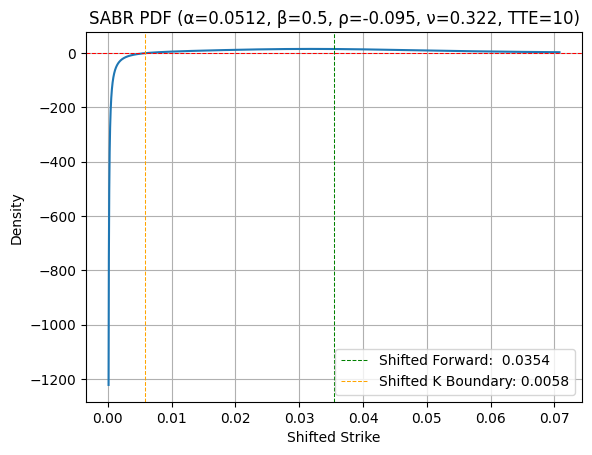

In [9]:
K_lo = 1e-4
K_hi = 2*forward
grid  = np.exp(np.linspace(np.log(K_lo), np.log(K_hi), 1000))

pdf, _ = SABRAnalytics.pdf_and_cdf(forward,tte,alpha,beta,rho,nu,grid,shift)
arbitrage_free, boundary_k = check_for_negative_density(grid, pdf)
    
# PDF Plot
plt.plot(grid, pdf)
plt.axhline(y=0, color='red', linestyle='--', lw=0.75)
plt.axvline(x=forward, color='green', linestyle='--', lw=0.75, label=f'Shifted Forward: {forward + shift: 0.4f}')
if boundary_k is not None:
    plt.axvline(x=boundary_k, color='orange', linestyle='--', lw=0.75, label=f'Shifted K Boundary: {boundary_k:0.4f}')
plt.title(f"SABR PDF (α={alpha}, β={beta}, ρ={rho}, ν={nu}, TTE={tte})")
plt.xlabel("Shifted Strike")
plt.ylabel("Density")
plt.grid()
plt.legend()

# 3. SABR Simulation and Density

For bump-and-revaluation calculations, please use the functions provided in `european_options.py`.

If an analytical solution is preferred, the corresponding implementation can be found in `sabr.py`.

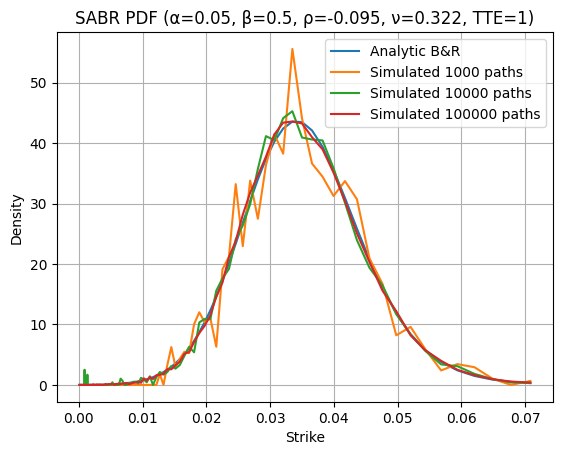

In [10]:
alpha = 0.05
beta = 0.5
nu = 0.322
rho = -9.5/100
shift = 0.0
forward = 3.54/100
tte = 1

K_lo = 1e-4
K_hi = 2*forward
grid  = np.exp(np.linspace(np.log(K_lo), np.log(K_hi), 150))

pdf, _ = SABRAnalytics.pdf_and_cdf(forward,tte,alpha,beta,rho,nu,grid,shift)
plt.plot(grid, pdf, label = "Analytic B&R")

for n_paths in [1000, 10000, 100000]:
    _, (edges, pdf) = SABRAnalytics.simulate_sabr_paths(forward, tte, alpha, beta, rho, nu, grid, num_paths=n_paths)
    # PDF Plot
    plt.plot(grid, pdf, label = f"Simulated {n_paths} paths")
plt.title(f"SABR PDF (α={alpha}, β={beta}, ρ={rho}, ν={nu}, TTE={tte})")
plt.xlabel("Strike")
plt.ylabel("Density")
plt.grid()
plt.legend(loc='best')

# 4. Quantile Map


In [11]:
import scipy
import scipy.interpolate
import scipy.stats


def generate_correalted_normals(n, m, corr, seed = 42):
    # n : no of correalted gaussians
    # m : samples 2^m instances of random numbers
    # corr : correlation matrix
    uniform_sampler = qmc.Sobol(d=n, seed=seed)
    uniform_iid_samples = uniform_sampler.random_base2(m)
    uniform_iid_samples = np.clip(uniform_iid_samples, 1e-8, 1 - 1e-8)
    normal_iid_samples = norm.ppf(uniform_iid_samples)

    try:
        L = np.linalg.cholesky(corr)
    except:
        raise ValueError("Correlation matrix must be positive definite")
    
    normal_corr_samples = normal_iid_samples @ L.T
    return normal_corr_samples

def quantile_mapping(F, tte, sigma_atm_normal, beta, rho, nu, shift, quantile_points):
    K_lo = 2*SABRAnalytics.EPSILON
    K_hi = F + 6*sigma_atm_normal*np.sqrt(tte)
    grid  = np.exp(np.linspace(np.log(K_lo), np.log(K_hi), quantile_points))
    
    alpha = SABRAnalytics.alpha_from_atm_normal_sigma(F,tte,sigma_atm_normal,beta,rho, nu,shift)[SabrMetrics.ALPHA]
    _, cdf = SABRAnalytics.pdf_and_cdf(F,tte,alpha, beta, rho, nu, grid, shift)

    cdf = np.clip(cdf, 1e-8, 1.0 - 1e-8)
    y = norm.ppf(cdf)
    _, uid = np.unique(y, return_index=True)
    return scipy.interpolate.interp1d(
        y[uid], grid[uid],
        kind="linear",
        bounds_error=False,
        fill_value=(grid[uid[0]], grid[uid[-1]])
    )

def spread_price(S1, S2, S1_S2_corr, K, mc_path_base_2, quantile_points = 1000):
    I1 = quantile_mapping(S1["forward"], S1["tte"], S1["normal_atm_vol"], S1["beta"], S1["rho"], S1["nu"], S1.get("shift", 0.0), quantile_points)
    I2 = quantile_mapping(S2["forward"], S2["tte"], S2["normal_atm_vol"], S2["beta"], S2["rho"], S2["nu"], S2.get("shift", 0.0), quantile_points)
    mc = generate_correalted_normals(2, mc_path_base_2, [[1.0, S1_S2_corr], [S1_S2_corr, 1.0]])
    S1_T = I1(mc[:,0])
    S2_T = I2(mc[:,1])
    payoff = np.maximum(S1_T-S2_T-K, 0)
    price = np.mean(payoff)
    print(f"S1(T) mean: {np.mean(S1_T)}")
    print(f"S2(T) mean: {np.mean(S2_T)}")
    print("Spread Option Price: ", price)

In [12]:
S1 = {
    "forward": 0.03,
    "normal_atm_vol": 0.01,
    "beta": 0.5,
    "nu": 0.2,
    "rho": 0.25,
    "tte": 1
}

S2 = {
    "forward": 0.05,
    "normal_atm_vol": 0.012,
    "beta": 0.5,
    "nu": 0.15,
    "rho": 0.45,
    "tte": 1
}

spread_price(S1, S2, S1_S2_corr=0.9, K = 0.001, mc_path_base_2 = 20, quantile_points = 1000)

S1(T) mean: 0.029999772961213964
S2(T) mean: 0.050000222342595095
Spread Option Price:  7.97906848228235e-08


# 5. Additional Problem

In [13]:
C = [[1, .9, .9],[.9, 1, -.9],[.9, -.9, 1]]
eigvals, eigvecs = np.linalg.eig(C)
print("Eigenvalues:", eigvals)

Eigenvalues: [ 1.9 -0.8  1.9]


The matrix is not positive semi-definte as it has a negative eigen-value. Intutively if the first variable is highly positively correlated with the second and third, then the second and third should also be positively correlated as well which is not the case.

$$\sum_{i,j} a_i a_j \rho_{i,j} = \sum_{i,j} \eta a_i a_j + \sum_{i,j} (1-\eta) a_i a_j e^{-\lambda|T_i - T_j|}$$

The first part,
$$\sum_{i,j} \eta a_i a_j = \sum_{i} a_i \sum_{j} a_j = \eta (\sum_{i} a_i)^2 \ge 0$$

The second part,
$$\sum_{i,j} (1-\eta) a_i a_j e^{-\lambda|T_i - T_j|} = \sum_{i,j} (1-\eta) a_i a_j \frac{2\lambda}{\pi}\int_{0}^{\infty} \frac{cos(\omega (T_i - T_j))}{\lambda^2 + \omega^2} d\omega$$
$$= (1-\eta)\frac{2\lambda}{\pi} \int_{0}^{\infty} \frac{1}{(\lambda^2 + \omega^2)} [\sum_{i,j} a_i a_j cos(\omega (T_i - T_j))]d\omega$$
$$= (1-\eta)\frac{2\lambda}{\pi} \int_{0}^{\infty} \frac{1}{(\lambda^2 + \omega^2)} [\sum_{i,j} a_i a_j cos(T_i)cos(T_j) +  a_i a_j sin(T_i)sin(T_j) ]d\omega$$
$$= (1-\eta)\frac{2\lambda}{\pi} \int_{0}^{\infty} \frac{1}{(\lambda^2 + \omega^2)} [\sum_{i} a_i cos(T_i) \sum_{j} a_j cos(T_j) +  \sum_{i} a_i sin(T_i) \sum_{j} a_j sin(T_j)]d\omega$$
$$= (1-\eta)\frac{2\lambda}{\pi} \int_{0}^{\infty} \frac{1}{(\lambda^2 + \omega^2)} [(\sum_{i} a_i cos(T_i))^2 +  (\sum_{i} a_i sin(T_i))^2]d\omega \ge 0$$

$$\implies \sum_{i,j} a_i a_j \rho_{i,j} \ge 0$$
Thus $\rho_{i,j}$ is positive semi-definite matrix.

In [14]:
import scipy
import scipy.optimize

def psd_corr(terms,eta,l):
    n = len(terms)
    A = np.zeros((n,n))
    for i in range(n):
        for j in range(n):
            A[i,j] = eta + (1-eta)*np.exp(-abs(terms[i]-terms[j])*l)

    return A

def closest_psd(terms, R):
    def objective(eta, l):
        est = psd_corr(terms, eta, l)
        d = est - R
        return scipy.linalg.norm(d, ord = 'fro')
    
    optimal_params = scipy.optimize.minimize(
        lambda x: objective(x[0], x[1]), 
        x0 = [0.5, 1], 
        bounds = [(0,1), (0, None)]
    )
    closest_psd_corr = psd_corr(terms, optimal_params.x[0], optimal_params.x[1])
    return closest_psd_corr

terms = [0.25, 1, 5] # Example terms for the correlation matrix
closest_psd_matrix = closest_psd(terms, C)
print("Closest PSD Correlation Matrix:\n", closest_psd_matrix)

Closest PSD Correlation Matrix:
 [[1.         0.63575573 0.05677692]
 [0.63575573 1.         0.08930618]
 [0.05677692 0.08930618 1.        ]]
